# Salifort Motors — Employee Attrition Analysis

## Business context
Salifort Motors' HR department wants to understand why employees leave
and to build a model that flags employees at high risk of attrition, so
leadership can act before losing valuable staff.

This notebook covers the full workflow: data cleaning, exploratory data
analysis (EDA), feature engineering, model building (tree-based models), 
evaluation, and business recommendations.



## 1. PACE: Plan

**Business question:** What factors are most associated with employees
leaving the company, and can we predict which current employees are at
risk?

**Stakeholders:** HR leadership, department managers.

**Deliverable:** An EDA summary of attrition drivers + a classification
model with performance metrics and actionable recommendations.


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)



## 2. PACE: Analyze — Load & Inspect Data

In [4]:
# Loading dataset into a dataframe
df = pd.read_csv("data/HR_Dataset_SaliMotors.csv")


In [ ]:
# Displaying first few rows of the dataframe
df.head()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [ ]:
# Gathering basic information about the data
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


In [ ]:
# Gathering descriptive statistics about the data
df.describe()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,0.526360,0.592967,3.919333,200.583333,4.021333,0.158000,0.209333,0.051333
std,0.220037,0.173633,1.271444,46.132438,1.772843,0.364863,0.406968,0.220750
min,0.050000,0.350000,2.000000,95.000000,2.000000,0.000000,0.000000,0.000000
25%,0.360000,0.440000,3.000000,168.000000,3.000000,0.000000,0.000000,0.000000
50%,0.540000,0.590000,4.000000,200.000000,4.000000,0.000000,0.000000,0.000000
75%,0.700000,0.740000,5.000000,231.000000,5.000000,0.000000,0.000000,0.000000
max,0.990000,0.990000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### 2.1 Data cleaning
Check for missing values, duplicates, and column-name issues.

In [ ]:
# Display all column names in the dataframe
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='str')

In [8]:
# Rename columns as needed
df = df.rename(columns={ 'average_montly_hours': 'average_monthly_hours',
                          'Work_accident': 'work_accident',
                          'time_spend_company' : 'tenure',
                          'Department': 'department'})
df.columns


Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='str')

In [ ]:
# Check for missing values
print("Missing values per column:")
print(df.isna().sum())


Missing values per column:
satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
tenure                   0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64


In [ ]:

#checking for duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())



Duplicate rows: 3008


In [ ]:
# Displaying the first few duplicate rows for inspection
df[df.duplicated()].head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low


In [9]:
# Drop duplicates and save resulting dataframe in a new variable as needed
df1 = df.drop_duplicates(keep='first')

# Display first few rows of new dataframe as needed
df1.head()


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


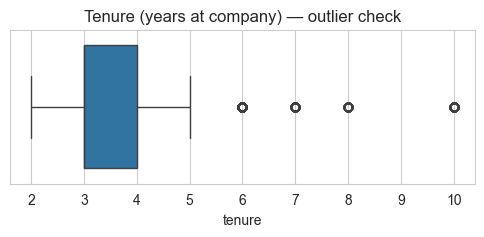

In [ ]:
# Check for outliers in tenure using a boxplot 
plt.figure(figsize=(6,2))
sns.boxplot(x=df1["tenure"])
plt.title("Tenure (years at company) — outlier check")
plt.show()


In [14]:
# Determining the number of rows containing outliers 

# Computing the 25th percentile value in `tenure`
percentile25 = df1['tenure'].quantile(0.25)

# Computing the 75th percentile value in `tenure`
percentile75 = df1['tenure'].quantile(0.75)

# Computing the interquartile range in `tenure`
iqr = percentile75 - percentile25

# Defining the upper limit and lower limit for non-outlier values in `tenure`
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr
print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

# Identifying subset of data containing outliers in `tenure`
outliers = df1[(df1['tenure'] > upper_limit) | (df1['tenure'] < lower_limit)]

# Counting how many rows in the data contain outliers in `tenure`
print("Number of rows in the data containing outliers in `tenure`:", len(outliers))

Lower limit: 1.5
Upper limit: 5.5
Number of rows in the data containing outliers in `tenure`: 824


Certain types of models are more sensitive to outliers than others. When we get to the stage of building our model, we will consider whether to remove these outliers based on the type of model we decide to use.

 # 3. Exploratory Data Analysis

## 3.1 Overall attrition rate

In [ ]:
attrition_rate = df["left"].mean()
print(f"Overall attrition rate: {attrition_rate:.1%}")


Overall attrition rate: 23.8%


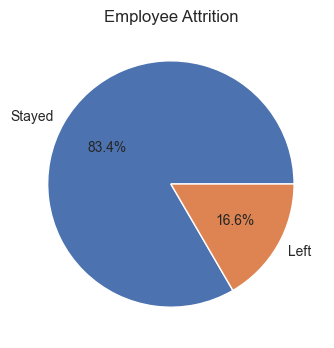

In [ ]:

# Visualizing the distribution of the target variable `left` using a pie chart
plt.figure(figsize=(4,4))
df1["left"].value_counts().plot.pie(
    labels=["Stayed", "Left"], autopct="%1.1f%%",
    colors=["#4C72B0", "#DD8452"]
)
plt.ylabel("")
plt.title("Employee Attrition")
plt.savefig("images/attrition_pie.png", dpi=120, bbox_inches="tight")
plt.show()


### 3.2 Satisfaction level vs. attrition

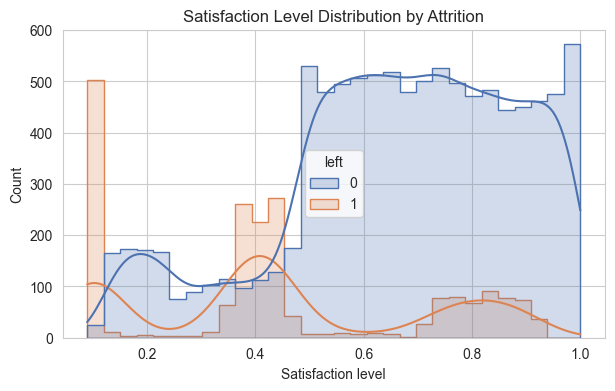

In [ ]:
plt.figure(figsize=(7,4))
sns.histplot(data=df1, x="satisfaction_level", hue="left", bins=30,
             kde=True, palette=["#4C72B0", "#DD8452"], element="step")
plt.title("Satisfaction Level Distribution by Attrition")
plt.xlabel("Satisfaction level")
plt.savefig("images/satisfaction_vs_attrition.png", dpi=120, bbox_inches="tight")
plt.show()


### 3.3 Workload: number of projects and monthly hours

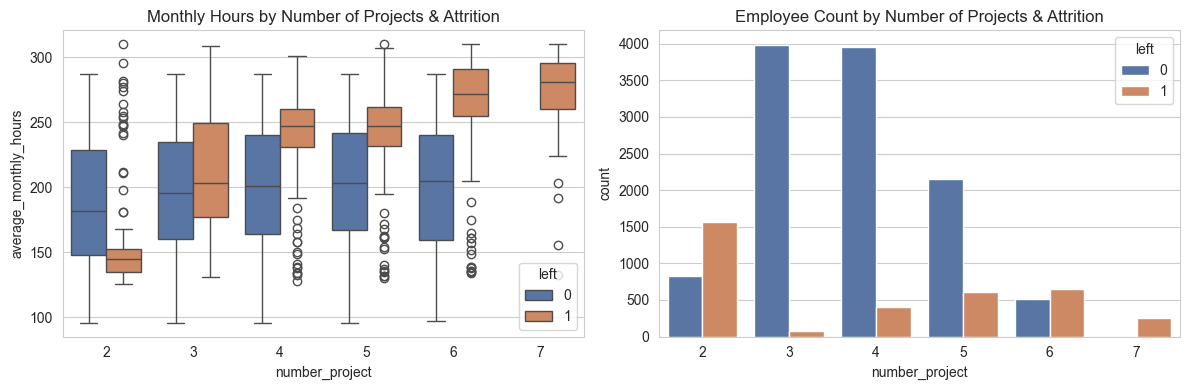

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.boxplot(data=df1, x="number_project", y="average_monthly_hours",
            hue="left", ax=axes[0], palette=["#4C72B0", "#DD8452"])
axes[0].set_title("Monthly Hours by Number of Projects & Attrition")

sns.countplot(data=df, x="number_project", hue="left", ax=axes[1],
              palette=["#4C72B0", "#DD8452"])
axes[1].set_title("Employee Count by Number of Projects & Attrition")

plt.tight_layout()
plt.savefig("images/workload_vs_attrition.png", dpi=120, bbox_inches="tight")
plt.show()


**Observation:** Employees with very few projects (2) *and* employees
with very many projects (6-7, paired with unusually high monthly hours)
show elevated attrition — suggesting two distinct risk groups: disengaged/
underutilized employees, and overworked/burned-out employees.

### 3.4 Tenure vs. attrition

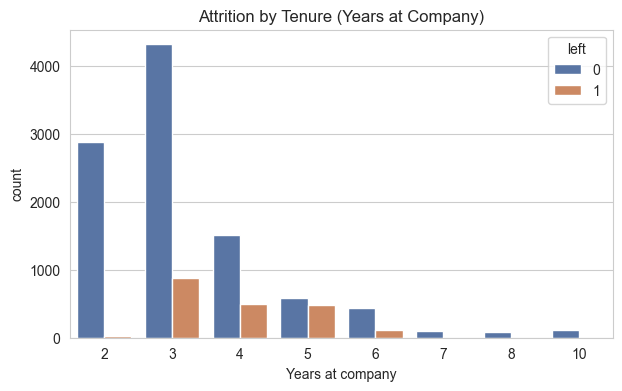

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(data=df1, x="tenure", hue="left",
              palette=["#4C72B0", "#DD8452"])
plt.title("Attrition by Tenure (Years at Company)")
plt.xlabel("Years at company")
plt.savefig("images/tenure_vs_attrition.png", dpi=120, bbox_inches="tight")
plt.show()


### 3.5 Salary level vs. attrition

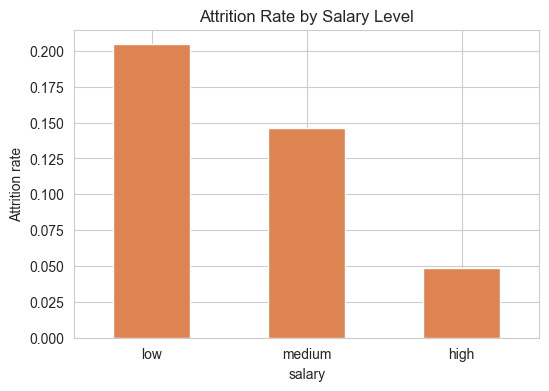

In [ ]:
plt.figure(figsize=(6,4))
salary_attrition = (df1.groupby("salary")["left"].mean()
                     .reindex(["low", "medium", "high"]))
salary_attrition.plot(kind="bar", color="#DD8452")
plt.ylabel("Attrition rate")
plt.title("Attrition Rate by Salary Level")
plt.xticks(rotation=0)
plt.savefig("images/salary_vs_attrition.png", dpi=120, bbox_inches="tight")
plt.show()


### 3.6 Correlation heatmap (numeric features)

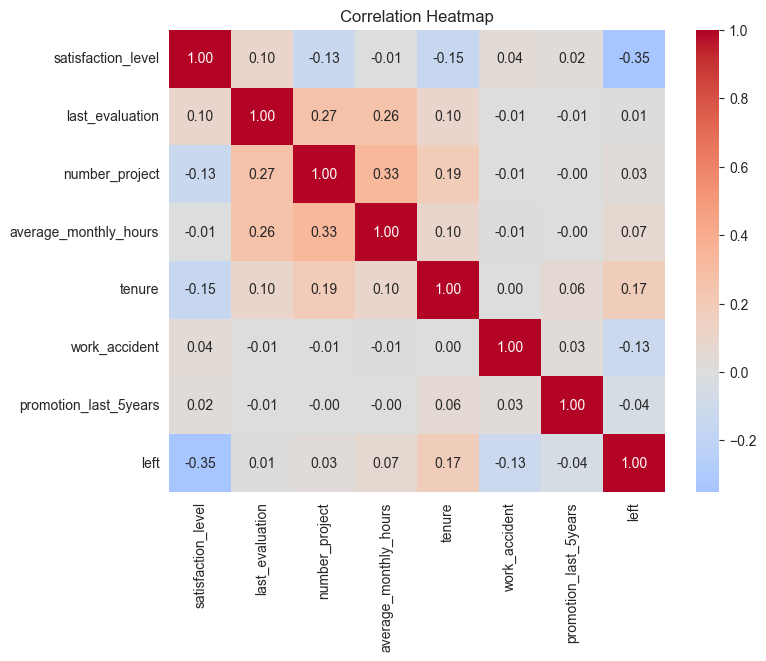

In [ ]:
numeric_cols = ["satisfaction_level", "last_evaluation", "number_project",
                 "average_monthly_hours", "tenure",
                 "work_accident", "promotion_last_5years", "left"]

plt.figure(figsize=(8,6))
sns.heatmap(df1[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0)
plt.title("Correlation Heatmap")
plt.savefig("images/correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()


**Key EDA takeaways:**
- The number of projects, monthly hours, and evaluation scores all have some positive correlation with each other, and whether an employee leaves is negatively correlated with their satisfaction level.
- It appears that employees are leaving the company as a result of poor management. Leaving is tied to longer working hours, many projects, and generally lower satisfaction levels. It can be ungratifying to work long hours and not receive promotions or good evaluation scores. There's a sizeable group of employees at this company who are probably burned out. It also appears that if an employee has spent more than six years at the company, they tend not to leave.


## 4. PACE: Construct — Feature Engineering & Modeling

In [12]:
# Copying the dataframe
model_df = df1.copy()

# Encoding the `salary` column as an ordinal numeric category
model_df['salary'] = (
    model_df['salary'].astype('category')
    .cat.set_categories(['low', 'medium', 'high'])
    .cat.codes
)

# Dummy encode the `department` column
model_df = pd.get_dummies(model_df, drop_first=False)

# Displaying the new dataframe
model_df.head()



,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False
1,0.80,0.86,5,262,6,0,1,0,1,False,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,1,0,1,False,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,1,0,0,False,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False


### Since logistic regression is quite sensitive to outliers, it would be a good idea at this stage to remove the outliers in the tenure column that were identified earlier.

In [15]:
# Select rows without outliers in `tenure` and save resulting dataframe in a new variable
df_logreg = model_df[(model_df['tenure'] >= lower_limit) & (model_df['tenure'] <= upper_limit)]

# Display first few rows of new dataframe
df_logreg.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,1,0,1,False,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,1,0,0,False,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False
5,0.41,0.50,2,153,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False


In [18]:
# isolating features and target variable

X = model_df.drop(columns=["left"])
y = model_df["left"]

#splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)

print(X_train.shape, X_test.shape)


(8993, 18) (2998, 18)


### 4.1 Baseline model: Logistic Regression

In [36]:
# Training a logistic regression model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["Stayed", "Left"]))
roc_auc = roc_auc_score(y_test, log_reg.predict_proba(X_test)[:, 1])
print("ROC-AUC score: ",roc_auc)


              precision    recall  f1-score   support

      Stayed       0.86      0.96      0.91      2500
        Left       0.51      0.18      0.27       498

    accuracy                           0.83      2998
   macro avg       0.68      0.57      0.59      2998
weighted avg       0.80      0.83      0.80      2998

ROC-AUC score:  0.8309815261044176


### 4.2 Tree-based model: Random Forest (with hyperparameter tuning)

In [29]:
# Instantiate model
rf = RandomForestClassifier(random_state=0)

# assigning hyperparameter values to test in the grid search
cv_params = {'max_depth': [3,5, None], 
             'max_features': [1.0],
             'max_samples': [0.7, 1.0],
             'min_samples_leaf': [1,2,3],
             'min_samples_split': [2,3,4],
             'n_estimators': [300, 500],
             }  
# Assign a dictionary of scoring metrics to capture
scoring = {'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall', 'f1': 'f1', 'roc_auc': 'roc_auc'}

# Instantiate GridSearch
rf1 = GridSearchCV(rf, cv_params, scoring=scoring, cv=4, refit='roc_auc')

# fit the model to the training data
rf1.fit(X_train, y_train)

print("Best params:", rf1.best_params_)
best_rf = rf1.best_estimator_


Best params: {'max_depth': 5, 'max_features': 1.0, 'max_samples': 1.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


In [35]:
y_pred_rf = best_rf.predict(X_test)

print(classification_report(y_test, y_pred_rf, target_names=["Stayed", "Left"]))
print("ROC-AUC:", round(roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1]), 3))


              precision    recall  f1-score   support

      Stayed       0.98      0.99      0.99      2500
        Left       0.95      0.92      0.94       498

    accuracy                           0.98      2998
   macro avg       0.97      0.96      0.96      2998
weighted avg       0.98      0.98      0.98      2998

ROC-AUC: 0.978


## 5. PACE: Execute — Evaluation & Insights

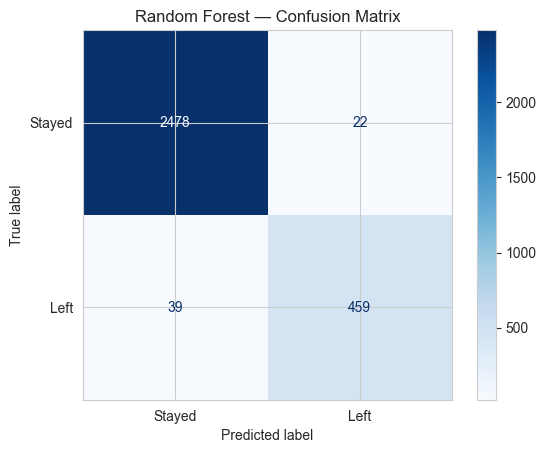

In [32]:
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(cm, display_labels=["Stayed", "Left"])
disp.plot(cmap="Blues")
plt.title("Random Forest — Confusion Matrix")
plt.savefig("images/confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()


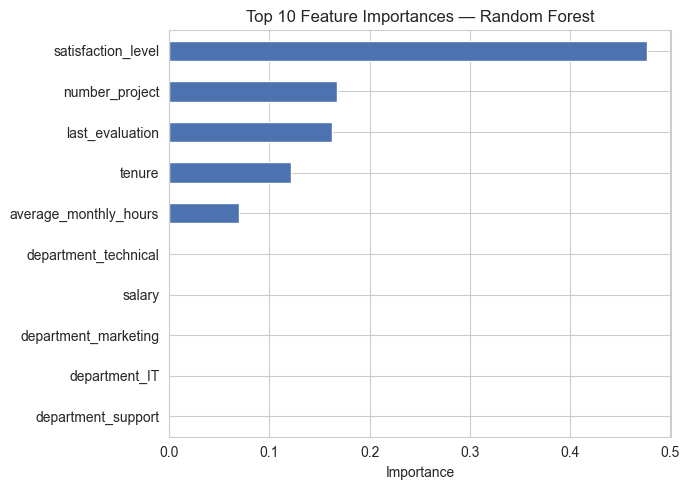

satisfaction_level       0.476676
number_project           0.167591
last_evaluation          0.162834
tenure                   0.122020
average_monthly_hours    0.070155
department_technical     0.000140
salary                   0.000119
department_marketing     0.000115
department_IT            0.000094
department_support       0.000089
dtype: float64

In [37]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(7,5))
top_features.sort_values().plot(kind="barh", color="#4C72B0")
plt.title("Top 10 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("images/feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

top_features


### Model comparison summary

| Model | Precision (Left) | Recall (Left) | F1 (Left) | ROC-AUC |
|---|---|---|---|---|
| Logistic Regression | 0.51 | 0.18 | 0.27 | 0.830 |
| Random Forest (tuned) | 0.95 | 0.92 | 0.94 | 0.978 |

The Random Forest trades some precision for much better recall on the
minority ('Left') class — meaning it catches more at-risk employees,
which matters more for a retention use case where missing a departure is
costlier than a false alarm. Results will vary slightly with the real
dataset and random seed.


## 6. Business Recommendations

1. **Watch workload extremes.** Employees on only 2 projects and
   employees on 6+ projects with very high monthly hours both show
   elevated attrition. HR should monitor both under- and over-allocation.
2. **Prioritize satisfaction as an early-warning signal.** Satisfaction
   level is the top predictor of attrition — regular pulse surveys could
   flag at-risk employees before they resign.
3. **Review the 4-6 year tenure band.** Retention programs (career
   development conversations, mobility options) could specifically target
   this group.
4. **Compensation review for low-salary bands.** While a smaller effect
   than workload, salary still contributes meaningfully to attrition risk.
5. **Operationalize the model.** The tuned Random Forest can score current
   employees monthly, surfacing a ranked "attrition risk" list for HR
   business partners to review — enabling proactive retention conversations
   rather than reactive exit interviews.

## 7. Next Steps


- Attrition has unobserved drivers like (manager quality, external job
  market, personal circumstances) not captured here.
- Test additional models (XGBoost), add manager-level
  features if available, and validate the model's fairness across
  departments and salary bands before deploying in production.
